##EDA ON RETAIL SALES DATA


1.Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
%matplotlib inline

Load Dataset

In [ ]:
df=pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


Initial inspection

In [ ]:
df.shape

(1000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [ ]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


2.Descriptive stastics:

In [ ]:
numerical=df.select_dtypes(include=np.number)

print("Mean")
print(numerical.mean())

Mean
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64


In [ ]:
print("Median")
print(numerical.median())

Median
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64


In [ ]:
print("Mode")
print(numerical.mode().iloc[0])

Mode
Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64


In [ ]:
print("Standard Deviation")
print(numerical.std())

Standard Deviation
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


3.Time series analysis

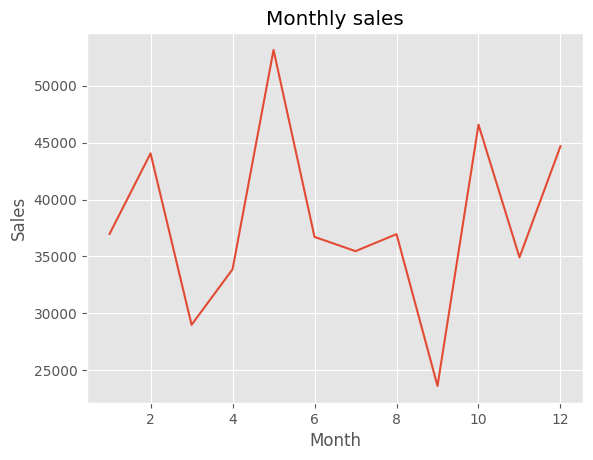

In [ ]:
#plot monthly and quarterly sales trends using charts


df["Date"]=pd.to_datetime(df["Date"]) #convert date


#monthly sales

monthly=df.groupby(df["Date"].dt.month)["Total Amount"].sum()
monthly.plot()
plt.title("Monthly sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

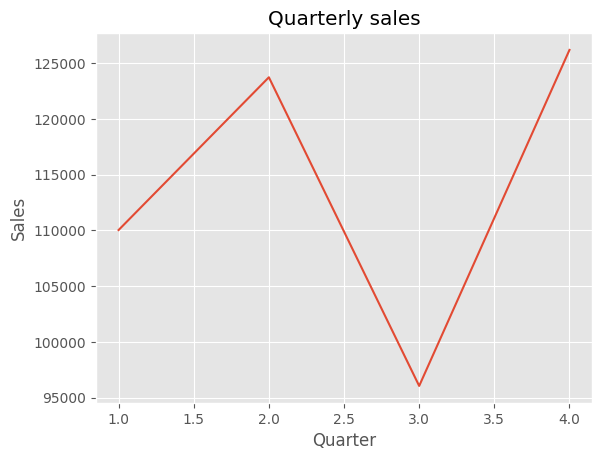

In [ ]:
#Quarterly sales

quarter=df.groupby(df['Date'].dt.quarter)['Total Amount'].sum()
quarter.plot()
plt.title("Quarterly sales")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.show()

4.Customer demographics analysis

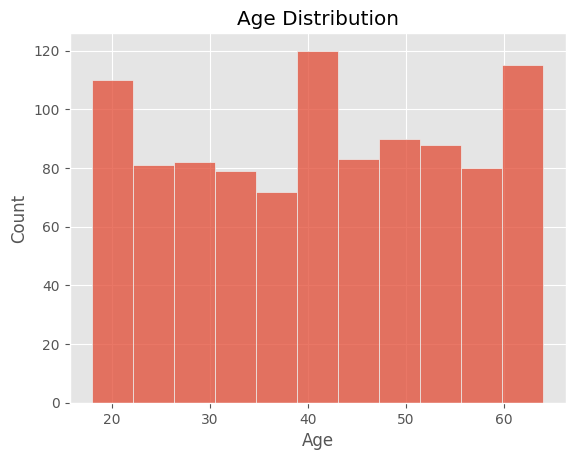

In [ ]:
#distribution of customer age groups\
sns.histplot(df['Age'])
plt.title("Age Distribution")
plt.show()

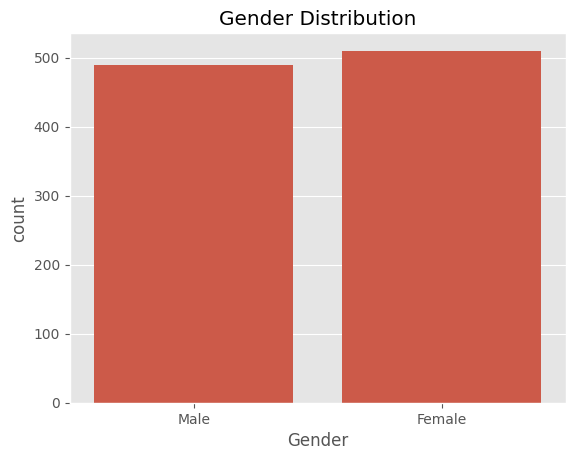

In [ ]:
#distribution of gender
sns.countplot(x='Gender',data=df)
plt.title("Gender Distribution")
plt.show()

5.product analysis

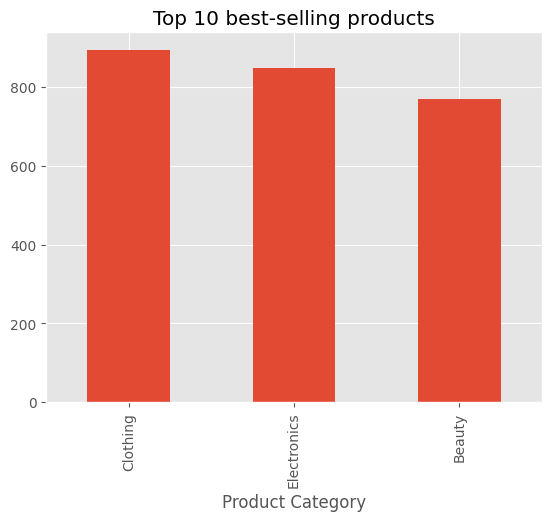

In [ ]:
#top 10 best-selling product

top=df.groupby("Product Category")["Quantity"].sum().sort_values(ascending=False).head(10)
top.plot(kind="bar")
plt.title("Top 10 best-selling products")

plt.show()

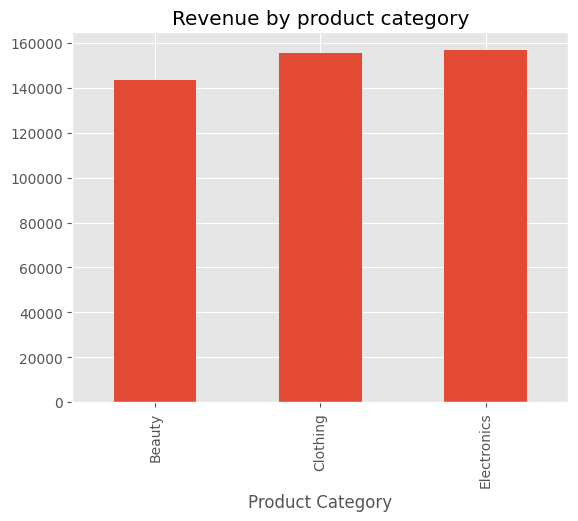

In [ ]:
#revenue by product category

revenue=df.groupby("Product Category")["Total Amount"].sum()
revenue.plot(kind="bar")
plt.title("Revenue by product category")
plt.show()

6.Heatmap

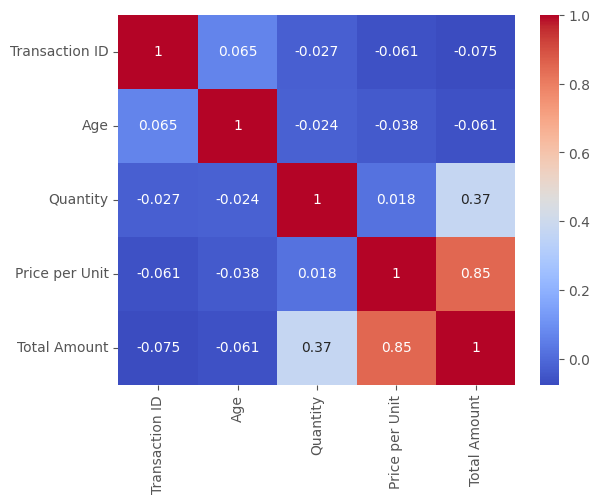

In [ ]:
#correlation matrix between numerical variables
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

6.additional chart

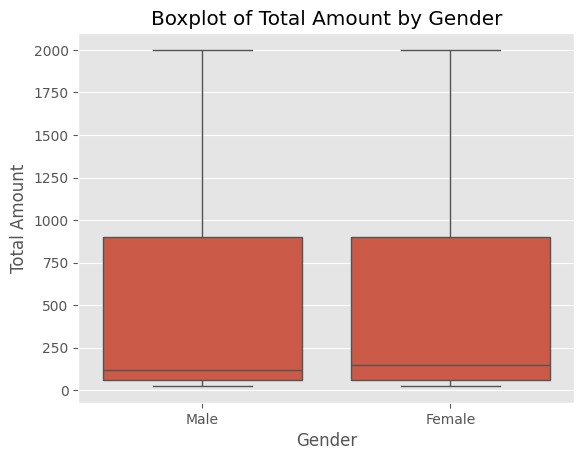

In [ ]:
sns.boxplot(x="Gender",y="Total Amount",data=df)
plt.title("Boxplot of Total Amount by Gender")
plt.show()

7.Conclusion

*   Best-selling product should be stocked more
*   Focus marketing during low-sales month
*   Promote the highest revenue product category




